# E-init: Forward Integration of the Euler–Lagrange Equation from First-Block Initial Conditions

**Objective.** Test whether the pair $(h_t^{(0)}, \vec v_t^{(0)}) = (h_t^{(0)}, h_t^{(1)} - h_t^{(0)})$ is sufficient boundary data to predict subsequent layer-wise hidden states $h_t^{(\ell)}$, $\ell \geq 2$, under the dissipation-adjusted Euler–Lagrange equation with per-layer Gaussian-well parameters and attention-mass $w_t^{(\ell)}$.

A positive result establishes the second-order Lagrangian reading of transformer hidden-state dynamics at the level of *integrated trajectories*, complementing the local STP-acceleration identity already established on GPT-2.

**Reference.** See `docs/E_init_execution_plan.md` for the full protocol, fallback tiers, and figure specifications. This notebook implements the minimum-viable per-token version.

---
## Stage 0 — Setup

Standard imports and device detection. Make sure you have `torch`, `transformers`, `numpy`, `scipy`, and `matplotlib` installed in the active kernel.

In [1]:
import os
import json
import time
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Tuple

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM


def _pick_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        try:
            torch.zeros(1, device="mps")
            return "mps"
        except Exception:
            pass
    return "cpu"


@dataclass
class Config:
    model_name: str = "gpt2"  # 12 layers, hidden dim 768
    device: str = field(default_factory=_pick_device)
    dtype: torch.dtype = field(default_factory=lambda: torch.float32)
    max_length: int = 64
    output_dir: str = "results"


cfg = Config()
os.makedirs(cfg.output_dir, exist_ok=True)
print(f"torch {torch.__version__}   device {cfg.device}   dtype {cfg.dtype}")
print(f"model {cfg.model_name}   output_dir {cfg.output_dir}")

torch 2.2.2   device mps   dtype torch.float32
model gpt2   output_dir results


---
## Stage 1 — Load Model and Tokenizer

Load GPT-2 small. We will enable both `output_hidden_states=True` and `output_attentions=True` per forward pass. For GPT-2 small this gives 13 hidden states (embedding + 12 blocks) and 12 attention matrices (one per block) per sentence.

In [2]:
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    cfg.model_name,
    torch_dtype=cfg.dtype,
    attn_implementation="eager",  # required so output_attentions returns real tensors
).to(cfg.device)
model.eval()

N_LAYERS = model.config.num_hidden_layers   # 12 for GPT-2 small
N_HEADS = model.config.num_attention_heads  # 12
D_HIDDEN = model.config.hidden_size         # 768

print(f"Loaded {cfg.model_name}")
print(f"  layers={N_LAYERS}, heads={N_HEADS}, hidden_dim={D_HIDDEN}")
print(f"  parameters={sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded gpt2
  layers=12, heads=12, hidden_dim=768
  parameters=124.4M


### Corpus

We start with the same 50-sentence, 5-domain corpus used in the STP-acceleration validation so results are directly comparable. You can top up by appending more sentences to `EXTRA_SENTENCES` below.

In [3]:
CORPUS = {
    "mathematics": [
        "The fundamental theorem of calculus establishes that differentiation and integration are inverse operations of each other.",
        "A metric space is a set together with a notion of distance between its elements, usually called points, that satisfies a set of axioms.",
        "Euler's identity connects the five most important numbers in mathematics through the equation e to the power of i pi plus one equals zero.",
        "The eigenvalues of a symmetric matrix are always real, and the eigenvectors corresponding to distinct eigenvalues are orthogonal.",
        "Godel's incompleteness theorems demonstrate that in any consistent formal system capable of expressing basic arithmetic there exist statements that can neither be proved nor disproved.",
        "The Riemann hypothesis conjectures that all non-trivial zeros of the Riemann zeta function have real part equal to one half.",
        "A group homomorphism preserves the algebraic structure by mapping the identity element to the identity element and products to products.",
        "The central limit theorem states that the sum of a large number of independent random variables tends toward a normal distribution regardless of the underlying distribution.",
        "Hilbert spaces generalize the notion of Euclidean space to infinite dimensions while retaining the structure of an inner product.",
        "The Lagrangian of a mechanical system equals the kinetic energy minus the potential energy and encodes the complete dynamics through the Euler-Lagrange equations.",
    ],
    "narrative": [
        "The old lighthouse keeper climbed the spiral staircase one last time, his weathered hands gripping the iron railing as the storm gathered outside.",
        "She found the letter tucked between the pages of a book she hadn't opened in years, the ink faded but the words still sharp enough to wound.",
        "The train pulled into the empty station at midnight, its headlamp cutting through the fog like a single unblinking eye.",
        "He sat on the porch watching the fireflies trace their erratic paths through the warm summer air while the radio played something slow and sad.",
        "The market was closing for the day and the vendors were packing up their unsold fruit, bruised peaches and overripe plums going back into crates.",
        "She ran through the forest with branches whipping at her face, the sound of the river growing louder with every desperate step.",
        "The children built a fort out of couch cushions and draped a bedsheet over the top, declaring it a castle that no adults could enter.",
        "He returned to the village after twenty years and found that the oak tree in the square had been cut down and replaced by a parking lot.",
        "The ship appeared on the horizon at dawn, its sails torn and its hull battered, carrying survivors of a voyage no one had expected to end.",
        "She opened the door to find the apartment exactly as she had left it, dust settled on every surface like a thin layer of forgotten time.",
    ],
    "scientific": [
        "Photosynthesis converts carbon dioxide and water into glucose and oxygen using light energy captured by chlorophyll molecules in the thylakoid membranes.",
        "The double helix structure of DNA consists of two antiparallel strands held together by hydrogen bonds between complementary base pairs adenine-thymine and guanine-cytosine.",
        "General relativity describes gravity not as a force but as the curvature of spacetime caused by the presence of mass and energy.",
        "Neurons communicate across synaptic clefts by releasing neurotransmitters that bind to receptors on the postsynaptic membrane and trigger ion channel opening.",
        "The cosmic microwave background radiation is the thermal remnant of the early universe, emitted approximately 380,000 years after the Big Bang when atoms first formed.",
        "Plate tectonics explains the movement of lithospheric plates driven by convection currents in the asthenosphere, producing earthquakes, volcanoes, and mountain ranges.",
        "Quantum entanglement describes a correlation between particles such that measuring the state of one instantaneously determines the state of the other regardless of distance.",
        "The mitochondrial electron transport chain transfers electrons through a series of protein complexes to generate a proton gradient that drives ATP synthesis.",
        "Black holes form when massive stars exhaust their nuclear fuel and collapse under their own gravity, creating a singularity surrounded by an event horizon.",
        "CRISPR-Cas9 is a genome editing tool that uses a guide RNA to direct the Cas9 nuclease to a specific DNA sequence where it makes a double-strand break.",
    ],
    "code_description": [
        "The function iterates over the input list, applies a filter predicate to each element, and collects the matching elements into a new list that is returned.",
        "A binary search tree maintains the invariant that for every node, all values in the left subtree are smaller and all values in the right subtree are larger.",
        "The garbage collector identifies unreachable objects by tracing references from root pointers and reclaims their memory for future allocations.",
        "Dependency injection decouples object creation from usage by passing required services through constructor parameters rather than instantiating them internally.",
        "The load balancer distributes incoming HTTP requests across a pool of backend servers using a round-robin algorithm with health check probes every thirty seconds.",
        "A database transaction groups multiple operations into an atomic unit that either commits all changes or rolls back entirely if any operation fails.",
        "The recursive function computes the Fibonacci sequence by returning the sum of the two preceding values with base cases returning zero and one respectively.",
        "Hash maps achieve average constant time lookups by computing a hash of the key and using it as an index into an array of buckets.",
        "The event loop processes asynchronous callbacks from a message queue, executing each callback to completion before moving to the next one in the queue.",
        "Backpropagation computes gradients of the loss function with respect to each weight by applying the chain rule layer by layer from the output to the input.",
    ],
    "conversational": [
        "I was thinking we could grab dinner at that new place on Fifth Street, the one with the rooftop patio, if you're not too tired after work.",
        "Did you see the game last night? I couldn't believe they came back from a twenty-point deficit in the fourth quarter to win by three.",
        "My neighbor's dog got out again this morning and I spent half an hour chasing it around the block before finally catching it near the park.",
        "I've been meaning to tell you that the meeting got moved to Thursday, so we have an extra day to finish the presentation slides.",
        "The traffic was absolutely terrible this morning, it took me almost two hours to get to the office when it usually takes thirty minutes.",
        "Do you remember that restaurant we went to on vacation last summer? I found out they just opened a second location near downtown.",
        "I'm trying to decide between the blue one and the red one but honestly they both look great so maybe I should just get both.",
        "She told me she's thinking about going back to school to study architecture, which is funny because she used to say she'd never set foot in a classroom again.",
        "Can you pick up some milk on the way home? We also need bread and I think we're almost out of coffee too.",
        "I finally finished that book you recommended and you were right, the ending was completely unexpected but somehow felt inevitable in retrospect.",
    ],
}

EXTRA_SENTENCES = []  # append more sentences here to grow the corpus

all_sentences: List[str] = []
all_domains: List[str] = []
for domain, sents in CORPUS.items():
    for s in sents:
        all_sentences.append(s)
        all_domains.append(domain)
for s in EXTRA_SENTENCES:
    all_sentences.append(s)
    all_domains.append("extra")

print(f"Corpus: {len(all_sentences)} sentences")

Corpus: 50 sentences


---
## Stage 2 — Multi-Layer Extraction

For each sentence we record:
- `hs`: hidden states at every layer, shape `(L+1, T, d)`
- `attn`: attention matrices at every layer and head, shape `(L, H, T, T)`
- `ptl`: per-token NTP loss, shape `(T-1,)`
- `tok_ids`: token ids, shape `(T,)`

Memory per sentence: ~1 MB for hidden states, ~1 MB for attention, at T=40, L=12, H=12, d=768. Storing 50 sentences uses ~100 MB — negligible on a 64 GB laptop.

The hidden states are kept on CPU in float32. Attention is kept in float32 as well for head-summing stability.

In [4]:
@dataclass
class MultiLayerTrajectory:
    sentence: str
    domain: str
    tok_ids: np.ndarray      # (T,)
    hs: np.ndarray           # (L+1, T, d)
    attn: np.ndarray         # (L, H, T, T)
    ptl: np.ndarray          # (T-1,)


@torch.no_grad()
def extract_multilayer(sentence: str, domain: str) -> MultiLayerTrajectory:
    enc = tokenizer(sentence, return_tensors="pt", truncation=True, max_length=cfg.max_length)
    ids = enc["input_ids"].to(cfg.device)

    out = model(ids, output_hidden_states=True, output_attentions=True)

    hs = torch.stack([h[0] for h in out.hidden_states], dim=0).float().cpu().numpy()     # (L+1, T, d)
    attn = torch.stack([a[0] for a in out.attentions], dim=0).float().cpu().numpy()      # (L, H, T, T)

    logits = out.logits[0].float()                                                        # (T, V)
    shift_logits = logits[:-1]
    shift_labels = ids[0, 1:]
    ptl = F.cross_entropy(shift_logits, shift_labels, reduction="none").cpu().numpy()     # (T-1,)

    return MultiLayerTrajectory(
        sentence=sentence,
        domain=domain,
        tok_ids=ids[0].cpu().numpy(),
        hs=hs,
        attn=attn,
        ptl=ptl,
    )


t0 = time.time()
trajectories: List[MultiLayerTrajectory] = []
for sent, dom in tqdm(list(zip(all_sentences, all_domains)), desc="Extracting"):
    trajectories.append(extract_multilayer(sent, dom))
print(f"Extracted {len(trajectories)} trajectories in {time.time() - t0:.1f}s")

T_lengths = [t.hs.shape[1] for t in trajectories]
print(f"  token lengths: min={min(T_lengths)}, max={max(T_lengths)}, mean={np.mean(T_lengths):.1f}")
print(f"  hidden shape per sentence: {trajectories[0].hs.shape}")
print(f"  attention shape per sentence: {trajectories[0].attn.shape}")

Extracting:   0%|          | 0/50 [00:00<?, ?it/s]

Extracted 50 trajectories in 7.1s
  token lengths: min=17, max=39, mean=28.3
  hidden shape per sentence: (13, 17, 768)
  attention shape per sentence: (12, 12, 17, 17)


---
## Stage 3 — Derived Quantities

We compute three derived arrays from the raw trajectories:

1. **Attention mass** $w_t^{(\ell)}$: column sum of the attention matrix at layer $\ell$, summed over heads. Shape `(L, T)` per sentence.
2. **Initial velocity** $\vec v_t^{(0)} = h_t^{(1)} - h_t^{(0)}$. Shape `(T, d)` per sentence.
3. **Per-layer centered hidden state** $\vec x_t^{(\ell)} = h_t^{(\ell)} - \mu^{(\ell)}$, where $\mu^{(\ell)}$ is the global per-layer mean across all tokens in the corpus. Shape `(L+1, T, d)` per sentence.

We also pool across all (sentence, token) pairs for per-layer Gaussian-well fitting.

In [5]:
# ---- 3.1 Attention mass ----
def attention_mass(attn: np.ndarray) -> np.ndarray:
    """Given attn of shape (L, H, T, T), return (L, T) column sums aggregated over heads."""
    col_sum = attn.sum(axis=2)    # (L, H, T), sum over queries
    return col_sum.sum(axis=1)    # (L, T),    sum over heads

# ---- 3.2 Initial velocity, per sentence ----
for t in trajectories:
    t.w = attention_mass(t.attn)              # (L, T)
    t.v0 = t.hs[1] - t.hs[0]                  # (T, d)

# ---- 3.3 Per-layer centroid across corpus ----
L_plus_1 = trajectories[0].hs.shape[0]
# Stack all tokens from all sentences at each layer
mu_per_layer = np.zeros((L_plus_1, D_HIDDEN), dtype=np.float32)
count = 0
for t in trajectories:
    mu_per_layer += t.hs.sum(axis=1)           # (L+1, d)
    count += t.hs.shape[1]
mu_per_layer /= count
print(f"Global per-layer centroid computed across {count} tokens.")
print(f"  mean |mu^(l)| per layer: {np.linalg.norm(mu_per_layer, axis=1).round(2)}")

# Centered hidden states, per sentence
for t in trajectories:
    t.x = t.hs - mu_per_layer[:, None, :]     # (L+1, T, d)

print(f"\nShapes check on first trajectory:")
print(f"  w (attention mass):      {trajectories[0].w.shape}")
print(f"  v0 (initial velocity):   {trajectories[0].v0.shape}")
print(f"  x (centered hidden):     {trajectories[0].x.shape}")

Global per-layer centroid computed across 1413 tokens.
  mean |mu^(l)| per layer: [  4.    46.47  52.88 120.04 129.61 138.59 146.03 154.1  163.59 176.88
 198.57 261.49 229.05]

Shapes check on first trajectory:
  w (attention mass):      (12, 17)
  v0 (initial velocity):   (17, 768)
  x (centered hidden):     (13, 17, 768)


---
## Stage 4 — Per-Layer Gaussian-Well Fit

At each layer $\ell \in \{1, \ldots, L\}$ we fit
$$V^{(\ell)}(x) = a^{(\ell)} \left(1 - e^{-b^{(\ell)} x^2}\right)$$
to the scatter of $(\|\vec x_t^{(\ell)}\|_2, \text{NTP loss}_t)$ pooled across the corpus.

The parameters correspond to $a = \mathfrak{m}\upsilon^2$ and $b = \kappa^2$. We use Euclidean distance (not cosine) so the integrator can operate on the full d-dimensional centered hidden state. Layer $\ell = 0$ (embedding) is not fitted because its tokens have not yet been subject to well-dynamics.

**Quality gate.** If $R^2$ at middle layers is < 0.05, the well fit is too poor and we cannot expect the integrator to work. In that case, pivot to per-sentence centering (see `docs/E_init_execution_plan.md` §13).

In [6]:
def gaussian_well(x, a, b):
    return a * (1.0 - np.exp(-b * x ** 2))


def fit_well_for_layer(x_per_token: np.ndarray, ptl_per_token: np.ndarray) -> Dict:
    """Fit Gaussian well to (|x|, energy) pairs."""
    d = np.linalg.norm(x_per_token, axis=1)
    mask = np.isfinite(d) & np.isfinite(ptl_per_token)
    d = d[mask]
    e = ptl_per_token[mask]
    if len(d) < 10:
        return {"a": 0.0, "b": 0.0, "r2": -np.inf, "n": len(d)}
    p0 = [e.max(), 1.0 / (d.std() ** 2 + 1e-8)]
    try:
        popt, _ = curve_fit(gaussian_well, d, e, p0=p0, maxfev=20000)
        pred = gaussian_well(d, *popt)
        ss_res = np.sum((e - pred) ** 2)
        ss_tot = np.sum((e - e.mean()) ** 2)
        r2 = 1.0 - ss_res / (ss_tot + 1e-12)
        return {"a": float(popt[0]), "b": float(popt[1]), "r2": float(r2), "n": len(d)}
    except RuntimeError:
        return {"a": 0.0, "b": 0.0, "r2": -np.inf, "n": len(d)}


# Pool (x, ptl) per layer. PTL is (T-1,), so we align with positions 0..T-2.
well_params: Dict[int, Dict] = {}
for ell in range(1, L_plus_1):
    x_pool = np.concatenate([t.x[ell, :-1, :] for t in trajectories], axis=0)       # (N, d)
    e_pool = np.concatenate([t.ptl for t in trajectories], axis=0)                   # (N,)
    well_params[ell] = fit_well_for_layer(x_pool, e_pool)

print(f"{'layer':>6} {'a':>10} {'b':>12} {'R^2':>10} {'N':>8}")
for ell, p in well_params.items():
    print(f"{ell:>6d} {p['a']:>10.3f} {p['b']:>12.6f} {p['r2']:>10.4f} {p['n']:>8d}")

 layer          a            b        R^2        N
     1      3.668     0.113355     0.0000     1363
     2      3.668     0.017868     0.0000     1363
     3      8.262     0.000055     0.0465     1363
     4      8.216     0.000047     0.0438     1363
     5      8.165     0.000042     0.0367     1363
     6      8.078     0.000039     0.0275     1363
     7      7.939     0.000036     0.0139     1363
     8      7.655     0.000035    -0.0133     1363
     9      7.545     0.000031    -0.0247     1363
    10      7.489     0.000027    -0.0286     1363
    11      7.650     0.000021    -0.0118     1363
    12      3.668     0.079694     0.0000     1363


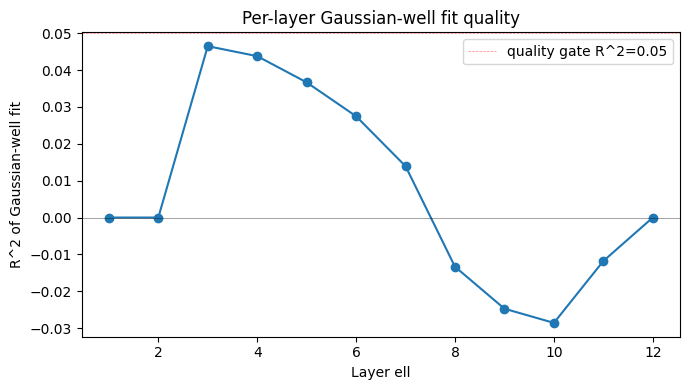

Layers passing quality gate (R^2 > 0.05): []


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
layers = list(well_params.keys())
r2s = [well_params[ell]["r2"] for ell in layers]
ax.plot(layers, r2s, marker="o", linewidth=1.5)
ax.axhline(0.0, color="k", linewidth=0.5, alpha=0.5)
ax.axhline(0.05, color="r", linewidth=0.5, linestyle="--", alpha=0.5, label="quality gate R^2=0.05")
ax.set_xlabel("Layer ell")
ax.set_ylabel("R^2 of Gaussian-well fit")
ax.set_title("Per-layer Gaussian-well fit quality")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "stage4_well_r2_vs_layer.png"), dpi=120)
plt.show()

good_layers = [ell for ell, p in well_params.items() if p["r2"] > 0.05]
print(f"Layers passing quality gate (R^2 > 0.05): {good_layers}")

---
## Stage 5 — Symplectic Euler Integrator

We integrate the dissipation-adjusted Euler–Lagrange equation
$$\mathfrak{m} \ddot{\vec x} = -2 a b \, \vec x \, e^{-b \|\vec x\|^2} - \mathfrak{m} \gamma \dot{\vec x}$$
forward through the layers. The mass $\mathfrak{m}_t = \bar w_t$ is the mean attention mass across the middle layers (ablatable). The well parameters are those fitted at each layer in Stage 4.

For layers that failed the quality gate, we substitute zero force (let inertia carry the trajectory).

In [8]:
def symplectic_euler_step(x: np.ndarray, v: np.ndarray,
                          a_ell: float, b_ell: float,
                          m: float, gamma: float,
                          dt: float = 1.0) -> Tuple[np.ndarray, np.ndarray]:
    """One integration step of (4.1). x, v are (d,) arrays."""
    r2 = np.dot(x, x)
    f_over_m = -2.0 * (a_ell / max(m, 1e-8)) * b_ell * x * np.exp(-b_ell * r2)
    v_new = (v + dt * f_over_m) / (1.0 + dt * gamma)
    x_new = x + dt * v_new
    return x_new, v_new


def integrate_trajectory(x0: np.ndarray, v0: np.ndarray,
                         m: float,
                         well_params: Dict[int, Dict],
                         L: int,
                         gamma: float = 0.0,
                         dt: float = 1.0,
                         r2_gate: float = 0.05) -> np.ndarray:
    """Integrate from layer 0 (x0, v0) forward through layers 1..L. Returns (L+1, d)."""
    x = x0.copy()
    v = v0.copy()
    traj = [x.copy()]
    for ell in range(1, L + 1):
        p = well_params[ell]
        if p["r2"] > r2_gate:
            a_ell, b_ell = p["a"], p["b"]
        else:
            a_ell, b_ell = 0.0, 0.0
        x, v = symplectic_euler_step(x, v, a_ell, b_ell, m, gamma, dt)
        traj.append(x.copy())
    return np.stack(traj, axis=0)


def static_null(x0: np.ndarray, L: int) -> np.ndarray:
    return np.tile(x0, (L + 1, 1))


def linear_null(x0: np.ndarray, v0: np.ndarray, L: int) -> np.ndarray:
    return x0[None, :] + np.arange(L + 1)[:, None] * v0[None, :]


# Sanity test on one (sentence, token): does the integrator run without blowing up?
traj0 = trajectories[0]
x0 = traj0.x[0, 0, :]
v0 = traj0.hs[1, 0, :] - traj0.hs[0, 0, :]
m = float(traj0.w[:, 0].mean())
pred = integrate_trajectory(x0, v0, m, well_params, L=N_LAYERS, gamma=0.0)
print(f"Sanity integration OK: shape {pred.shape}, final |x| = {np.linalg.norm(pred[-1]):.3f}")
print(f"Observed final centered |x|: {np.linalg.norm(traj0.x[-1, 0, :]):.3f}")
print(f"Observed |h|: {np.linalg.norm(traj0.hs[-1, 0, :]):.3f}    |mu^L|: {np.linalg.norm(mu_per_layer[-1]):.3f}")

Sanity integration OK: shape (13, 768), final |x| = 1570.820
Observed final centered |x|: 153.521
Observed |h|: 78.148    |mu^L|: 229.048


---
## Stage 6 — Full-Corpus Residuals

For every (sentence, token) pair, and for every integrator variant, we compute the per-layer relative residual
$$\rho_t^{(\ell)} = \frac{\|\hat h_t^{(\ell)} - h_t^{(\ell)}\|}{\|h_t^{(\ell)}\|}$$
where $\hat h_t^{(\ell)} = \hat x_t^{(\ell)} + \mu^{(\ell)}$ converts the integrator output back to absolute hidden-state coordinates.

We stack residuals across all tokens into arrays of shape `(N_tokens, L+1)` for each variant.

In [9]:
def compute_all_residuals(gamma: float) -> Dict[str, np.ndarray]:
    """Compute per-token residuals at every layer for E-init, static null, linear null."""
    rho_einit: List[np.ndarray] = []
    rho_static: List[np.ndarray] = []
    rho_linear: List[np.ndarray] = []
    w_list: List[np.ndarray] = []

    for traj in trajectories:
        T = traj.hs.shape[1]
        for ti in range(T):
            x0 = traj.x[0, ti, :]
            v0 = traj.hs[1, ti, :] - traj.hs[0, ti, :]
            m = float(np.clip(traj.w[:, ti].mean(), 1e-3, None))
            # Predicted centered trajectories (L+1, d)
            pred_x = integrate_trajectory(x0, v0, m, well_params, L=N_LAYERS, gamma=gamma)
            static_x = static_null(x0, L=N_LAYERS)
            linear_x = linear_null(x0, v0, L=N_LAYERS)
            # Convert back to absolute hidden-state coordinates
            pred_h = pred_x + mu_per_layer
            static_h = static_x + mu_per_layer
            linear_h = linear_x + mu_per_layer
            obs_h = traj.hs[:, ti, :]
            denom = np.linalg.norm(obs_h, axis=1) + 1e-8
            rho_einit.append(np.linalg.norm(pred_h - obs_h, axis=1) / denom)
            rho_static.append(np.linalg.norm(static_h - obs_h, axis=1) / denom)
            rho_linear.append(np.linalg.norm(linear_h - obs_h, axis=1) / denom)
            w_list.append(float(traj.w[:, ti].mean()))

    return {
        "einit": np.stack(rho_einit, axis=0),      # (N_tokens, L+1)
        "static": np.stack(rho_static, axis=0),
        "linear": np.stack(rho_linear, axis=0),
        "w_mean": np.array(w_list),                # (N_tokens,)
    }


print("Computing residuals for gamma=0 (conservative)...")
R0 = compute_all_residuals(gamma=0.0)
print(f"  shape: {R0['einit'].shape}")
print(f"  median layer-L E-init residual: {np.median(R0['einit'][:, -1]):.3f}")
print(f"  median layer-L static null:    {np.median(R0['static'][:, -1]):.3f}")
print(f"  median layer-L linear null:    {np.median(R0['linear'][:, -1]):.3f}")

Computing residuals for gamma=0 (conservative)...


  shape: (1413, 13)
  median layer-L E-init residual: 2.804
  median layer-L static null:    0.192
  median layer-L linear null:    2.804


---
## Stage 7 — Gamma Calibration

Sweep $\gamma \in \{0, 0.05, 0.1, 0.2, 0.5\}$ and pick the value that minimises the median layer-$L$ E-init residual. Small values suggest near-conservative dynamics; larger values suggest strong dissipation. A monotonic improvement then plateau is healthy; a u-shape with a clear minimum at $\gamma^\star > 0$ is the predicted regime for a bound attractor with Rayleigh damping.

In [10]:
gammas = [0.0, 0.05, 0.1, 0.2, 0.5]
sweep: Dict[float, Dict[str, np.ndarray]] = {}
for g in gammas:
    print(f"Computing for gamma = {g} ...")
    sweep[g] = compute_all_residuals(gamma=g)

median_final = {g: float(np.median(sweep[g]["einit"][:, -1])) for g in gammas}
for g, m in median_final.items():
    print(f"  gamma={g:.2f}  median layer-L E-init residual = {m:.4f}")

gamma_star = min(median_final, key=median_final.get)
print(f"\nChosen gamma* = {gamma_star}  (median residual {median_final[gamma_star]:.4f})")

R_star = sweep[gamma_star]

Computing for gamma = 0.0 ...


Computing for gamma = 0.05 ...


Computing for gamma = 0.1 ...


Computing for gamma = 0.2 ...


Computing for gamma = 0.5 ...


  gamma=0.00  median layer-L E-init residual = 2.8038
  gamma=0.05  median layer-L E-init residual = 2.0717
  gamma=0.10  median layer-L E-init residual = 1.5940
  gamma=0.20  median layer-L E-init residual = 1.0423
  gamma=0.50  median layer-L E-init residual = 0.4821

Chosen gamma* = 0.5  (median residual 0.4821)


---
## Stage 8 — Figures

### Figure A: residual vs layer

Four curves: E-init conservative ($\gamma = 0$), E-init calibrated ($\gamma = \gamma^\star$), static null, linear null. Each with interquartile band.

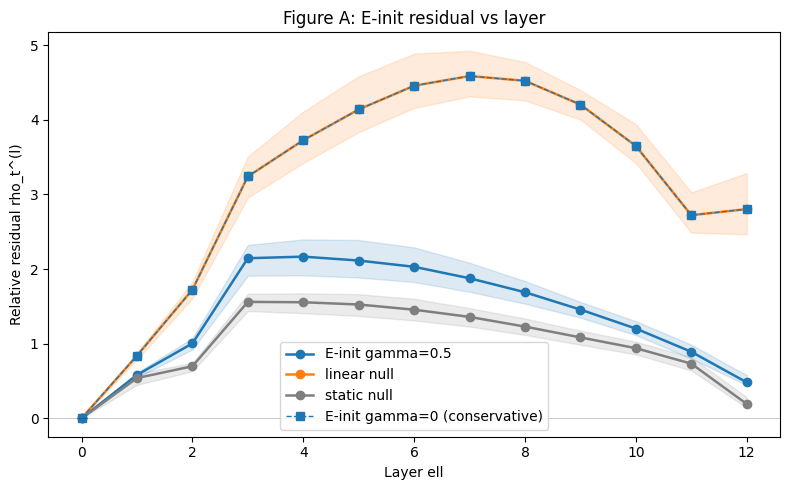

In [11]:
def percentile_band(arr: np.ndarray):
    median = np.median(arr, axis=0)
    lo = np.percentile(arr, 25, axis=0)
    hi = np.percentile(arr, 75, axis=0)
    return median, lo, hi

fig, ax = plt.subplots(figsize=(8, 5))
layers = np.arange(N_LAYERS + 1)

for key, label, color in [
    ("einit", f"E-init gamma={gamma_star}", "tab:blue"),
    ("linear", "linear null", "tab:orange"),
    ("static", "static null", "tab:gray"),
]:
    m, lo, hi = percentile_band(R_star[key])
    ax.plot(layers, m, marker="o", label=label, color=color, linewidth=1.8)
    ax.fill_between(layers, lo, hi, color=color, alpha=0.15)

m0, _, _ = percentile_band(sweep[0.0]["einit"])
ax.plot(layers, m0, marker="s", label="E-init gamma=0 (conservative)",
        color="tab:blue", linewidth=1.0, linestyle="--")

ax.set_xlabel("Layer ell")
ax.set_ylabel("Relative residual rho_t^(l)")
ax.set_title("Figure A: E-init residual vs layer")
ax.axhline(0.0, color="k", linewidth=0.5, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "fig_A_residual_vs_layer.png"), dpi=150)
plt.show()

### Figure B: residual at layer $L$ vs $\log w_t$

The second-order theory predicts a *downward* trend: heavier tokens are predicted more accurately by the integrator.

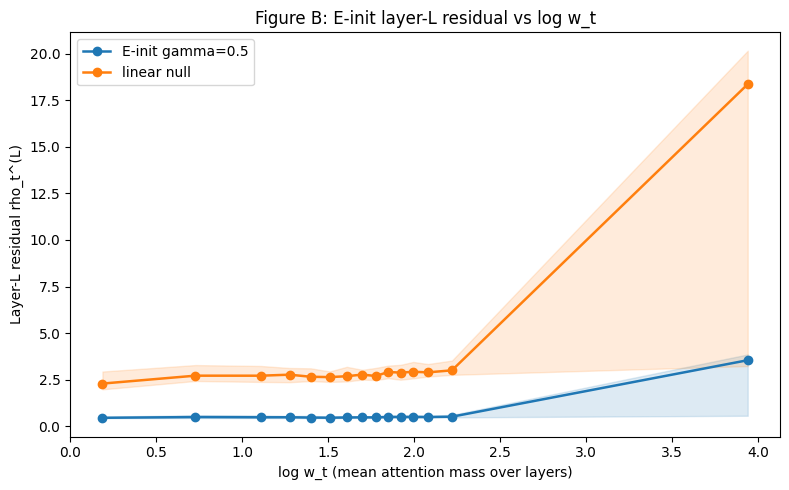

Binned regression of E-init layer-L residual on log w_t:
  slope = 0.7359   (negative = heavier tokens predicted better)
  intercept = -0.5604


In [12]:
N_BINS = 15

log_w = np.log(np.clip(R_star["w_mean"], 1e-3, None))
bins = np.quantile(log_w, np.linspace(0, 1, N_BINS + 1))
bin_centers = 0.5 * (bins[1:] + bins[:-1])
bin_idx = np.clip(np.digitize(log_w, bins) - 1, 0, N_BINS - 1)

def binned(arr_layer_L):
    medians = np.full(N_BINS, np.nan)
    los = np.full(N_BINS, np.nan)
    his = np.full(N_BINS, np.nan)
    for i in range(N_BINS):
        mask = bin_idx == i
        if mask.sum() >= 3:
            vals = arr_layer_L[mask]
            medians[i] = np.median(vals)
            los[i] = np.percentile(vals, 25)
            his[i] = np.percentile(vals, 75)
    return medians, los, his

fig, ax = plt.subplots(figsize=(8, 5))
for key, label, color in [
    ("einit", f"E-init gamma={gamma_star}", "tab:blue"),
    ("linear", "linear null", "tab:orange"),
]:
    m, lo, hi = binned(R_star[key][:, -1])
    ax.plot(bin_centers, m, marker="o", label=label, color=color, linewidth=1.8)
    ax.fill_between(bin_centers, lo, hi, color=color, alpha=0.15)

ax.set_xlabel("log w_t (mean attention mass over layers)")
ax.set_ylabel("Layer-L residual rho_t^(L)")
ax.set_title("Figure B: E-init layer-L residual vs log w_t")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "fig_B_residual_vs_logw.png"), dpi=150)
plt.show()

# Slope of E-init residual vs log w in the binned regression
m_e, _, _ = binned(R_star["einit"][:, -1])
valid = np.isfinite(m_e)
if valid.sum() >= 3:
    slope, intercept = np.polyfit(bin_centers[valid], m_e[valid], 1)
    print(f"Binned regression of E-init layer-L residual on log w_t:")
    print(f"  slope = {slope:.4f}   (negative = heavier tokens predicted better)")
    print(f"  intercept = {intercept:.4f}")

---
## Stage 9 — Cache Results

Save a single `.npz` with all residuals + well params + γ-sweep for later analysis and for the paper subsection.

In [13]:
save_path = os.path.join(cfg.output_dir, "e_init_results.npz")
np.savez(
    save_path,
    mu_per_layer=mu_per_layer,
    gamma_star=np.array([gamma_star]),
    gammas=np.array(gammas),
    median_final=np.array([median_final[g] for g in gammas]),
    rho_einit_star=R_star["einit"],
    rho_static_star=R_star["static"],
    rho_linear_star=R_star["linear"],
    w_mean=R_star["w_mean"],
    rho_einit_conservative=sweep[0.0]["einit"],
)

with open(os.path.join(cfg.output_dir, "well_params.json"), "w") as f:
    json.dump({str(k): v for k, v in well_params.items()}, f, indent=2)

print(f"Cached to {save_path}")
print(f"Wrote well params to {os.path.join(cfg.output_dir, 'well_params.json')}")

# Summary line for the paper
print("\n=== Summary ===")
print(f"  gamma*                                       = {gamma_star}")
print(f"  median layer-L E-init residual (gamma*)       = {np.median(R_star['einit'][:, -1]):.4f}")
print(f"  median layer-L E-init residual (conservative) = {np.median(sweep[0.0]['einit'][:, -1]):.4f}")
print(f"  median layer-L linear null residual           = {np.median(R_star['linear'][:, -1]):.4f}")
print(f"  median layer-L static null residual           = {np.median(R_star['static'][:, -1]):.4f}")

Cached to results/e_init_results.npz
Wrote well params to results/well_params.json

=== Summary ===
  gamma*                                       = 0.5
  median layer-L E-init residual (gamma*)       = 0.4821
  median layer-L E-init residual (conservative) = 2.8038
  median layer-L linear null residual           = 2.8038
  median layer-L static null residual           = 0.1924


---
## Next steps

Depending on the outcome (see `docs/E_init_execution_plan.md` §10–§11):

- **Strong positive** (E-init beats linear null by 2×+ on median layer-L residual, downward slope in Figure B): proceed to write the new subsection in `paper/sections/13_experiments.tex`.
- **Moderate** (E-init beats linear null by 1.2–2× only, weak Figure B trend): consider `gamma_star` sensitivity, per-sentence centering, or removing attention-sink tokens from the analysis.
- **Null** (E-init comparable to linear null): fall back to the Signpost-only tier; the §15 signpost already in the paper retains priority.

Send the figures and the summary-line numbers from Stage 9 back to Claude for interpretation and paper-integration.

---
## Stage 10 — Per-Sentence Centering Rerun (Tier-2 fallback)

The global-centering run above failed at the Stage-4 quality gate: the Gaussian-well fit
$V^{(\ell)}(r) = a(1 - e^{-b r^{2}})$ had $R^{2} < 0.05$ at every layer, so the integrator
received zero force and degenerated to damped ballistic motion. The static null ("just keep $x\_0$")
then beat E-init at every layer.

The STP-acceleration notebook already showed that meaningful energy-landscape fits on GPT-2 need
**per-sentence centering**, because different sentences occupy different directions in the
residual stream. With global centering the per-token radius $\|x\_t^{(\ell)}\|$ carries no coherent
relation to per-token loss, so the well cannot be identified.

Below we redo the pipeline with per-sentence per-layer centroids
$\mu^{(\ell)}\_{s} = \frac{1}{T\_{s}}\sum\_{t} h\_t^{(\ell)}$ for sentence $s$.
All downstream steps (well fit, integrator, residuals, figures, caching) are recomputed and
written with a `_ps` suffix, leaving the original global-centering artifacts intact for
comparison.

 layer          a            b        R^2        N
     1      3.668     0.098623     0.0000     1363
     2      3.668     0.020625     0.0000     1363
     3      8.015     0.000058     0.0486     1363
     4      7.993     0.000050     0.0472     1363
     5      7.976     0.000044     0.0421     1363
     6      7.926     0.000041     0.0340     1363
     7      7.850     0.000038     0.0236     1363
     8      7.643     0.000036    -0.0005     1363
     9      7.540     0.000033    -0.0111     1363
    10      7.420     0.000030    -0.0198     1363
    11      7.534     0.000024    -0.0026     1363
    12      3.668     0.070233     0.0000     1363


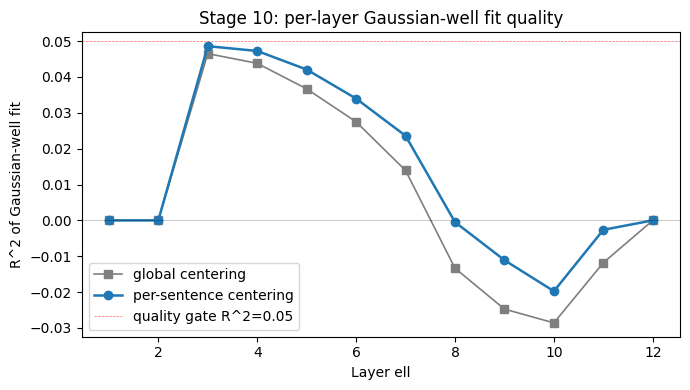

Layers passing quality gate with per-sentence centering (R^2 > 0.05): []


In [14]:
# ---- 10.1 Per-sentence centering + Gaussian-well refit ----

for tr in trajectories:
    tr.mu_ps = tr.hs.mean(axis=1, keepdims=True)        # (L+1, 1, d) per-sentence centroid per layer
    tr.x_ps = tr.hs - tr.mu_ps                           # (L+1, T, d) per-sentence centered

# Stage-4 refit using per-sentence centered radii
well_params_ps: Dict[int, Dict] = {}
for ell in range(1, L_plus_1):
    x_pool = np.concatenate([tr.x_ps[ell, :-1, :] for tr in trajectories], axis=0)   # (N, d)
    e_pool = np.concatenate([tr.ptl for tr in trajectories], axis=0)                   # (N,)
    well_params_ps[ell] = fit_well_for_layer(x_pool, e_pool)

print(f"{'layer':>6} {'a':>10} {'b':>12} {'R^2':>10} {'N':>8}")
for ell, p in well_params_ps.items():
    print(f"{ell:>6d} {p['a']:>10.3f} {p['b']:>12.6f} {p['r2']:>10.4f} {p['n']:>8d}")

fig, ax = plt.subplots(figsize=(7, 4))
layers = list(well_params_ps.keys())
r2s_ps = [well_params_ps[ell]["r2"] for ell in layers]
r2s_g  = [well_params[ell]["r2"]    for ell in layers]
ax.plot(layers, r2s_g,  marker="s", linewidth=1.2, label="global centering", color="tab:gray")
ax.plot(layers, r2s_ps, marker="o", linewidth=1.8, label="per-sentence centering", color="tab:blue")
ax.axhline(0.05, color="r", linewidth=0.5, linestyle="--", alpha=0.6, label="quality gate R^2=0.05")
ax.axhline(0.00, color="k", linewidth=0.5, alpha=0.3)
ax.set_xlabel("Layer ell")
ax.set_ylabel("R^2 of Gaussian-well fit")
ax.set_title("Stage 10: per-layer Gaussian-well fit quality")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "stage10_well_r2_vs_layer_ps.png"), dpi=120)
plt.show()

good_layers_ps = [ell for ell, p in well_params_ps.items() if p["r2"] > 0.05]
print(f"Layers passing quality gate with per-sentence centering (R^2 > 0.05): {good_layers_ps}")

In [15]:
# ---- 10.2 Residuals with per-sentence centering ----

def compute_all_residuals_ps(gamma: float) -> Dict[str, np.ndarray]:
    """Same as compute_all_residuals, but with per-sentence per-layer centroids."""
    rho_einit: List[np.ndarray] = []
    rho_static: List[np.ndarray] = []
    rho_linear: List[np.ndarray] = []
    w_list: List[float] = []

    for tr in trajectories:
        mu_ps = tr.mu_ps[:, 0, :]          # (L+1, d) per-sentence centroid per layer
        T = tr.hs.shape[1]
        for ti in range(T):
            x0 = tr.x_ps[0, ti, :]
            v0 = tr.x_ps[1, ti, :] - tr.x_ps[0, ti, :]
            m = float(np.clip(tr.w[:, ti].mean(), 1e-3, None))
            pred_x   = integrate_trajectory(x0, v0, m, well_params_ps, L=N_LAYERS, gamma=gamma)
            static_x = static_null(x0, L=N_LAYERS)
            linear_x = linear_null(x0, v0, L=N_LAYERS)
            pred_h   = pred_x   + mu_ps
            static_h = static_x + mu_ps
            linear_h = linear_x + mu_ps
            obs_h = tr.hs[:, ti, :]
            denom = np.linalg.norm(obs_h, axis=1) + 1e-8
            rho_einit.append(np.linalg.norm(pred_h   - obs_h, axis=1) / denom)
            rho_static.append(np.linalg.norm(static_h - obs_h, axis=1) / denom)
            rho_linear.append(np.linalg.norm(linear_h - obs_h, axis=1) / denom)
            w_list.append(float(tr.w[:, ti].mean()))

    return {
        "einit":  np.stack(rho_einit,  axis=0),
        "static": np.stack(rho_static, axis=0),
        "linear": np.stack(rho_linear, axis=0),
        "w_mean": np.array(w_list),
    }


gammas_ps = [0.0, 0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0]
sweep_ps: Dict[float, Dict[str, np.ndarray]] = {}
for g in gammas_ps:
    print(f"Computing (per-sentence) for gamma = {g} ...")
    sweep_ps[g] = compute_all_residuals_ps(gamma=g)

median_final_ps = {g: float(np.median(sweep_ps[g]["einit"][:, -1])) for g in gammas_ps}
for g, m in median_final_ps.items():
    print(f"  gamma={g:.2f}  median layer-L E-init residual = {m:.4f}")

gamma_star_ps = min(median_final_ps, key=median_final_ps.get)
print(f"\nChosen gamma*_ps = {gamma_star_ps}  (median residual {median_final_ps[gamma_star_ps]:.4f})")
R_star_ps = sweep_ps[gamma_star_ps]

print(f"\n--- Layer-L summary (per-sentence centering) ---")
for name, key in [("E-init (gamma*_ps)", "einit"), ("linear null", "linear"), ("static null", "static")]:
    x = R_star_ps[key][:, -1]
    print(f"  {name:>22}: median={np.median(x):.4f}  p25={np.percentile(x,25):.4f}  p75={np.percentile(x,75):.4f}")
print(f"  {'E-init (gamma=0, ps)':>22}: median={np.median(sweep_ps[0.0]['einit'][:, -1]):.4f}")

Computing (per-sentence) for gamma = 0.0 ...


Computing (per-sentence) for gamma = 0.05 ...


Computing (per-sentence) for gamma = 0.1 ...


Computing (per-sentence) for gamma = 0.2 ...


Computing (per-sentence) for gamma = 0.35 ...


Computing (per-sentence) for gamma = 0.5 ...


Computing (per-sentence) for gamma = 0.75 ...


Computing (per-sentence) for gamma = 1.0 ...


  gamma=0.00  median layer-L E-init residual = 1.4414
  gamma=0.05  median layer-L E-init residual = 1.0655
  gamma=0.10  median layer-L E-init residual = 0.8229
  gamma=0.20  median layer-L E-init residual = 0.5518
  gamma=0.35  median layer-L E-init residual = 0.3716
  gamma=0.50  median layer-L E-init residual = 0.2910
  gamma=0.75  median layer-L E-init residual = 0.2307
  gamma=1.00  median layer-L E-init residual = 0.2064

Chosen gamma*_ps = 1.0  (median residual 0.2064)

--- Layer-L summary (per-sentence centering) ---
      E-init (gamma*_ps): median=0.2064  p25=0.1715  p75=0.2757
             linear null: median=1.4414  p25=1.1227  p75=1.8167
             static null: median=0.1773  p25=0.1344  p75=0.2519
    E-init (gamma=0, ps): median=1.4414


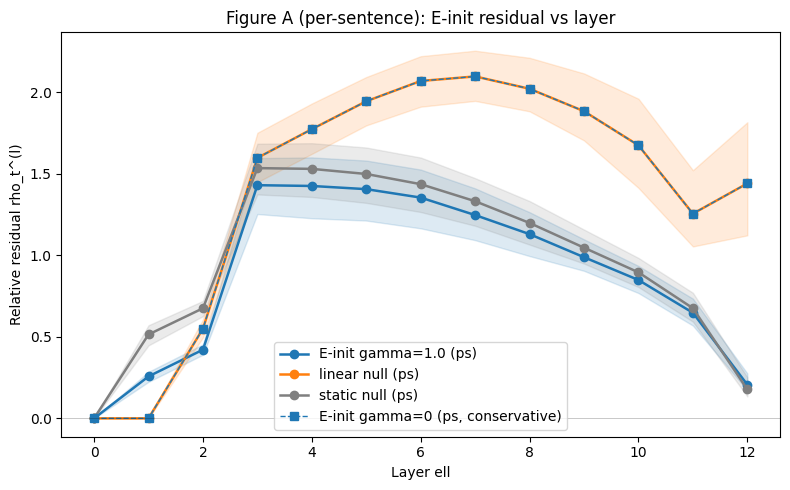

In [16]:
# ---- 10.3 Figure A (per-sentence) ----

fig, ax = plt.subplots(figsize=(8, 5))
layers = np.arange(N_LAYERS + 1)

for key, label, color in [
    ("einit",  f"E-init gamma={gamma_star_ps} (ps)", "tab:blue"),
    ("linear", "linear null (ps)",                    "tab:orange"),
    ("static", "static null (ps)",                    "tab:gray"),
]:
    m, lo, hi = percentile_band(R_star_ps[key])
    ax.plot(layers, m, marker="o", label=label, color=color, linewidth=1.8)
    ax.fill_between(layers, lo, hi, color=color, alpha=0.15)

m0, _, _ = percentile_band(sweep_ps[0.0]["einit"])
ax.plot(layers, m0, marker="s", label="E-init gamma=0 (ps, conservative)",
        color="tab:blue", linewidth=1.0, linestyle="--")

ax.set_xlabel("Layer ell")
ax.set_ylabel("Relative residual rho_t^(l)")
ax.set_title("Figure A (per-sentence): E-init residual vs layer")
ax.axhline(0.0, color="k", linewidth=0.5, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "fig_A_residual_vs_layer_ps.png"), dpi=150)
plt.show()

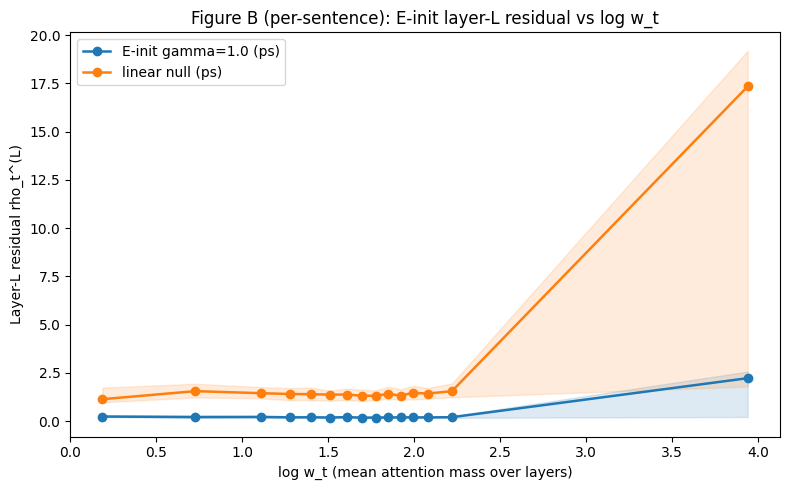

Binned regression of per-sentence E-init layer-L residual on log w_t:
  slope     = 0.4726   (negative = heavier tokens predicted better)
  intercept = -0.4588


In [17]:
# ---- 10.4 Figure B (per-sentence) + mass-slope regression ----

N_BINS = 15
log_w_ps = np.log(np.clip(R_star_ps["w_mean"], 1e-3, None))
bins_ps = np.quantile(log_w_ps, np.linspace(0, 1, N_BINS + 1))
bin_centers_ps = 0.5 * (bins_ps[1:] + bins_ps[:-1])
bin_idx_ps = np.clip(np.digitize(log_w_ps, bins_ps) - 1, 0, N_BINS - 1)

def binned_ps(arr_layer_L):
    medians = np.full(N_BINS, np.nan)
    los = np.full(N_BINS, np.nan)
    his = np.full(N_BINS, np.nan)
    for i in range(N_BINS):
        mask = bin_idx_ps == i
        if mask.sum() >= 3:
            vals = arr_layer_L[mask]
            medians[i] = np.median(vals)
            los[i] = np.percentile(vals, 25)
            his[i] = np.percentile(vals, 75)
    return medians, los, his

fig, ax = plt.subplots(figsize=(8, 5))
for key, label, color in [
    ("einit",  f"E-init gamma={gamma_star_ps} (ps)", "tab:blue"),
    ("linear", "linear null (ps)",                    "tab:orange"),
]:
    m, lo, hi = binned_ps(R_star_ps[key][:, -1])
    ax.plot(bin_centers_ps, m, marker="o", label=label, color=color, linewidth=1.8)
    ax.fill_between(bin_centers_ps, lo, hi, color=color, alpha=0.15)

ax.set_xlabel("log w_t (mean attention mass over layers)")
ax.set_ylabel("Layer-L residual rho_t^(L)")
ax.set_title("Figure B (per-sentence): E-init layer-L residual vs log w_t")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "fig_B_residual_vs_logw_ps.png"), dpi=150)
plt.show()

m_e, _, _ = binned_ps(R_star_ps["einit"][:, -1])
valid = np.isfinite(m_e)
slope_ps, intercept_ps = (np.nan, np.nan)
if valid.sum() >= 3:
    slope_ps, intercept_ps = np.polyfit(bin_centers_ps[valid], m_e[valid], 1)
    print(f"Binned regression of per-sentence E-init layer-L residual on log w_t:")
    print(f"  slope     = {slope_ps:.4f}   (negative = heavier tokens predicted better)")
    print(f"  intercept = {intercept_ps:.4f}")

In [18]:
# ---- 10.5 Cache per-sentence results and final summary ----

save_path_ps = os.path.join(cfg.output_dir, "e_init_results_ps.npz")
np.savez(
    save_path_ps,
    gamma_star_ps=np.array([gamma_star_ps]),
    gammas_ps=np.array(gammas_ps),
    median_final_ps=np.array([median_final_ps[g] for g in gammas_ps]),
    rho_einit_star_ps=R_star_ps["einit"],
    rho_static_star_ps=R_star_ps["static"],
    rho_linear_star_ps=R_star_ps["linear"],
    w_mean_ps=R_star_ps["w_mean"],
    rho_einit_conservative_ps=sweep_ps[0.0]["einit"],
    slope_ps=np.array([slope_ps]),
    intercept_ps=np.array([intercept_ps]),
)
with open(os.path.join(cfg.output_dir, "well_params_ps.json"), "w") as f:
    json.dump({str(k): v for k, v in well_params_ps.items()}, f, indent=2)

print(f"Cached per-sentence run to {save_path_ps}")

print("\n=== Summary (per-sentence centering) ===")
print(f"  gamma*_ps                                     = {gamma_star_ps}")
print(f"  median layer-L E-init residual (gamma*_ps)    = {np.median(R_star_ps['einit'][:, -1]):.4f}")
print(f"  median layer-L E-init residual (ps, gamma=0)  = {np.median(sweep_ps[0.0]['einit'][:, -1]):.4f}")
print(f"  median layer-L linear null residual (ps)      = {np.median(R_star_ps['linear'][:, -1]):.4f}")
print(f"  median layer-L static null residual (ps)      = {np.median(R_star_ps['static'][:, -1]):.4f}")
print(f"  slope(rho_L vs log w_t)                       = {slope_ps:.4f}")
print(f"  # layers passing R^2>0.05 quality gate (ps)   = {len([1 for p in well_params_ps.values() if p['r2']>0.05])} / {len(well_params_ps)}")

Cached per-sentence run to results/e_init_results_ps.npz

=== Summary (per-sentence centering) ===
  gamma*_ps                                     = 1.0
  median layer-L E-init residual (gamma*_ps)    = 0.2064
  median layer-L E-init residual (ps, gamma=0)  = 1.4414
  median layer-L linear null residual (ps)      = 1.4414
  median layer-L static null residual (ps)      = 0.1773
  slope(rho_L vs log w_t)                       = 0.4726
  # layers passing R^2>0.05 quality gate (ps)   = 0 / 12
